# 2. Pytorch Neural Network Classification

# 분류 문제 (classification problem) 
: 어떤 대상이 어떤 범주에 속하는지를 예측하는 문제

- 문제 유형
1. 이진 분류 (binary classification) : 결과가 두 가지 중 하나인 경우(예. 예/아니오) <br>
ex. 사람의 건강 지표를 바탕으로 심장병이 있는지 없는지 예측

2. 다중 분류 (Multi-class classification) : 결과가 두 개보다 많은 경우<br>
ex. 사진이 음식인지, 사람인지, 개인지 구분

3. 다중 라벨 분류 (Multi-lable classification) : 하나의 대상에 여러 개의 라벨을 동시에 부여할 수 있는 경우<br>
ex. 위키피디아 문서에 수학, 과학, 철학 같은 여러 카테고리를 예측

- 분류는 회귀(Regression)(숫자를 예측하는 문제)와 함께 머신러닝에서 가장 흔한 문제 유형 중 하나<br>
- 이번 목표-입력 데이터들의 집합이 주어졌을 때, 그 입력들이 어떤 클래스에 속하는지 예측하는 것<br>

# classification problem workflow

0. 분류 신경망의 구조 (Architecture of a classification neural network)<br>
신경망의 어떤 형태/크기로도 만들 수 있지만, 보통 기본 구조 따름

1. 이진 분류 데이터 준비 (Getting binary classification data ready)<br>
데이터는 무엇이든 될 수 있지만, 시작을 위해 간단한 이진 분류 데이터셋 생성

2. Pytorch 분류 모델 만들기 (Building a Pytorch classification model) <br>
데이터의 패턴을 학습할 모델을 만들고, 손실 함수(loss function) & optimizer 선택한 후 분류 문제에 맞는 학습 루프(training loop) 생성

3. 데이터에 모델 맞추기 (학습)(Fitting the model evaluating a model) <br>
데이터와 모델이 준비 되었으니, 모델이 학습 데이터에서 패턴을 찾도록 학습시킴

4. 예측 및 모델 평가 (추론) (Making predeictions and evaluating a model)<br>
모델이 데이터에서 찾은 패턴을 실제 테스트 데이터와 비교

5. 모델 개선하기 (모델 관점에서) (Improving a model)<br>
모델을 학습하고 평가했지만 성능이 별로인 경우, 여러 방법으로 개선해봄

6. 비선형성 (Non-linearity)<br>
지금까지 모델은 직선만 표현할 수 있었는데, 비선형(곡선)은 어떻게 다룰 수 있을까?

7. 비선형 함수 재현하기 (Replicating non-linear functions)<br>
비선형 데이터를 모델링하기 위해 사용한 비선형 함수들이 실제로 어떤 형태인지 살펴봄

8. 다중 클래스 분류로 마무리 (Putting it all together with multi-class classification)<br>
지금까지 배운 이진 분류 개념을 모두 종합해 다중 클래스 분류 문제에 적용


# 0. 분류 신경망의 구조 (Architecture of a classification neural network)

# 하이퍼파라미터 - 이진 분류 (Binary Classification) - 다중 클래스 분류 (Multiclass Classification)

입력층 형태 (Input layer shape / in_features) - 특성(feature) 개수와 동일 (예. 심장병 예측에서 나이, 성별, 키, 몸무게, 흡연 여부 -> 5 ) - 이진 분류와 동일 <br>
은닉층 (Hidden layer) - 문제 따라 다름, 최소 1개, 최대 제한 X - 이진 분류와 동일 <br>
은닉층 당 뉴런 수 - 문제 따라 다름, 보통 10~ 512 - 이진 분류와 동일 <br>
출력층 형태 (output layer shape/ out_featurs) - 1 (두 클래스 중 하나) - 클래스 개수만큼 (예. 음식 / 사람 / 개 -> 3)
은닉층 활성화 함수 - 보통 ReLU (Rectified Linear Unit), 그 외 다양한 함수 가능 - 이진 분류와 동일
출력층 활성화 함수 - sigmoid(torch.sigmoid in Pytorch) - Softmax (torch.softmax in PyTorch)
손실 함수 (Loss function) - 이진 크로스 엔트로피 (torch.nn.BCELoss) - 크로스 엔트로피 (torch.nn.CrossEntropyLoss)
Optimizer - SGD, Adam 등 (torch.optim 참고) - 이진 분류와 동일

# 1. 분류 데이터 만들고 준비

- Scikit-Learn의 make_circles() 함수 사용해 서로 다른 색의 점으로 이루어진 두 개의 원 형태 데이터 생성




In [1]:
import sklearn
print(sklearn.__version__)

1.7.2


In [2]:
from sklearn.datasets import make_circles


# 데이터 샘플 개수 1000개 생성
n_samples = 1000

# Create circles
X, y = make_circles(
    n_samples,
    noise=0.03, # 점들에 약간의 노이즈 추가
    random_state=42 # 코드 재실행해도 같은 데이터 값 갖기 위해 랜덤 시드 고정
)
print(f"First 5 X features:\n{X[:5]}")
print(f"\nFirst 5 y labels:\n{y[:5]}")

First 5 X features:
[[ 0.75424625  0.23148074]
 [-0.75615888  0.15325888]
 [-0.81539193  0.17328203]
 [-0.39373073  0.69288277]
 [ 0.44220765 -0.89672343]]

First 5 y labels:
[1 1 1 1 0]


--> y 값 하나당 X 값이 두 개씩 있는 것처럼 보임 <br>
시각화라는 데이터 탐색기(data explorer)의 모토를 따라가서, 이 데이터를 pandas DataFrame에 넣기

*pandas : 표 형태의 데이터(DataFrame)를 다루는 데 사용됨

In [3]:
import pandas as pd
pd.__version__

'2.3.3'

In [4]:
# 원형 데이터로 dataframe 만들기
import pandas as pd 

circles = pd.DataFrame({"X1" : X[:, 0],    #원형(circle) 데이터를 pandas DataFrame으로 변환
    "X2" : X[:, 1],
    "label" : y
})
circles.head(10)    #DataFrame 앞에서부터 10개 행을 출력. 데이터가 제대로 들어갔는지 확인

,X1,X2,label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0
5,-0.479646,0.676435,1
6,-0.013648,0.803349,1
7,0.771513,0.147760,1
8,-0.169322,-0.793456,1
9,-0.121486,1.021509,0


각 X 특성 쌍(X1과 X2)마다 라벨(y)값이 0 또는 1로 하나씩 붙어 있는 것처럼 보임
-> 선택지가 두가지(0 또는 1)
--> 이진 분류(Binary Classification)

In [5]:
# 라벨 개수 세기
circles["label"].value_counts()

label
1    500
0    500
Name: count, dtype: int64

In [6]:
circles.columns

Index(['X1', 'X2', 'label'], dtype='object')

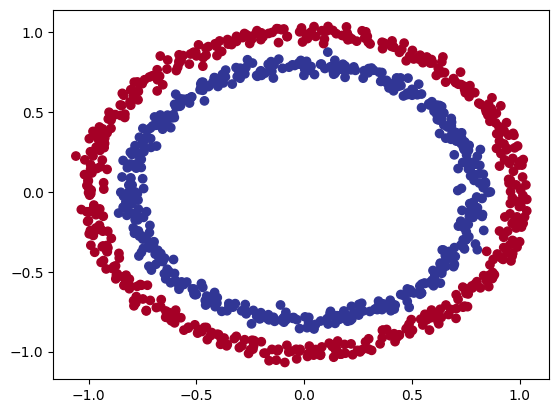

In [7]:
# 점 이용해서 시각화
import matplotlib.pyplot as plt

plt.scatter(        # 산점도 그리는 함수
    x=X[:, 0],      # X의 첫 번째 열 (X1 좌표)
    y=X[:, 1],      # X의 두 번째 열 (X2 좌표)
    c=y,            # 점의 색을 y값으로 지정
    cmap=plt.cm.RdYlBu
);

*선형 모델로는 한계가 있어서 원 모양

- 이 과정은 분류의 핵심 개념을 잘 보여줌
- 숫자 형태의 데이터, 데이터를 분류할 수 있는 모델을 만드는 것이 목적
- 점들을 빨강/파란색으로 나누는 것

# 1.1 ) 입력과 출력의 형태 (input and output shapes)

- 딥러닝에서 가장 흔한 오류 -> shape 오류
- 텐서의 형태와 텐서 연산의 형태가 맞지 않으면 모델에서 에러 발생

- 오류들이 절대 발생하지 않게 하는 방법은 없음 <br>
 --> 좋은 방법 : 다루고 있는 데이터의 형태를 계속해서 확인하고 익숙해지는 것 <br>
** 내 입력 데이터의 shape와 출력 데이터의 shape 늘 확인하기

In [8]:
# 특성(입력 데이터)과 라벨(정답)의 형태 확인
X.shape,  y.shape

((1000, 2), (1000,))

-> 첫 번째 차원은 둘 다 1000개이므로 잘 맞음

- X의 두 번째 차원은 무엇인지 헷갈릴 때 <br>
-> 하나의 샘플(특성과 라벨)의 값과 shape를 직접 확인해보기 <br>
--> 이러면 모델에서 어떤 입력 형태와 출력 형태를 기대해야 하는지를 잘 이해 가능 <br>

In [9]:
# 특성과 라벨의 첫 번째 예시 확인
X_sample = X[0]
y_sample = y[0]
print(f"X의 값 중 하나의 예시:{X_sample} 그리고 같은 예시의 y: {y_sample} ")
print(f" 예시 X 값의 형태 : {X_sample.shape} 그리고 예시 y 값의 형태: {y_sample.shape}")

X의 값 중 하나의 예시:[0.75424625 0.23148074] 그리고 같은 예시의 y: 1 
 예시 X 값의 형태 : (2,) 그리고 예시 y 값의 형태: ()


-> X의 두 번째 차원이 두개의 특성을 가지고 있음 (즉, 벡터 형태) <br>
-> y는 하나의 특성만 가짐(스칼라) <br>
--> 출력 하나를 예측하기 위해 입력은 두 개가 있는 구조 <br>


  # 1.2) 데이터를 텐서로 변환하고 학습(train)과 테스트(train) 세트로 나누기
 - pytorch에서 사용하고 모델링 할 수 있도록 데이터 준비

 1. 데이터를 텐서로 변환 <br>
 현재 데이터는 NunPy 배열 형태인데 pytorch는 pytorch 텐서를 사용하는 것이 더 적합

 2. 데이터를 학습용(train)과 테스트용(test)용으로 분리 <br>
 학습 세트(train set)는 모델이 X와 y 사이의 패턴 학습하는데 사용,<br> 테스트 세트(test set)는 학습된 패턴이 얼마나 잘 일반화되는지 평가하는데 사용



In [10]:
# 1. 데이터를 텐서로 변환
# 변환하지 않으면 문제 발생할 수도
import torch
X = torch.from_numpy(X).type(torch.float)
# torch.from_numpy(X) -> numpy 배열 x를 pytorch 텐서로 변환
# type(torch.float) -> 텐서의 자료형을 float32로 변환

y = torch.from_numpy(y).type(torch.float) # 위와 같은 작업을 y에 대해 수행하여 X와 y의 타입 맞춤

# 앞에서부터 5개 샘플들 확인
X[:5], y[:5]

(tensor([[ 0.7542,  0.2315],
         [-0.7562,  0.1533],
         [-0.8154,  0.1733],
         [-0.3937,  0.6929],
         [ 0.4422, -0.8967]]),
 tensor([1., 1., 1., 1., 0.]))

- 학습용(training) 세트와 테스트용(test) 세트로 나누기 <br>
test_size = 0.2 : 전테 데이터의 80%는 학습용, 20%는 테스트용으로 사용하다는 의미 <br>
random_state = 42 : 데이터 분할이 항상 무작위로 이루어지기 때문에 항상 동일하게 재현하도록 사용

In [11]:
# 2. 학습용(training) 세트와 테스트용(test) 세트로 나누기
from sklearn.model_selection import train_test_split 
#sklearn.model_selection 모듈에서 train_test_split 함수 가져옴 -> 이 함수는 데이터를 랜덤으로 섞은 뒤 train / test로 나눠줌

X_train, X_test, y_train, y_test = train_test_split(                                                           
                                                    X,
                                                    y,
                                                    test_size =0.2,   # 20% test, 80% train
                                                    random_state=42)
len(X_train), len(X_test), len(y_train), len(y_test)

(800, 200, 800, 200)

# 2. 모델 설계 

1. 디바이스에 독립적인 코드 설정 (CPU 또는 GPU가 사용 가능할 경우 어디서든 모델이 실행될 수 있도록)
2. nn.Module을 상속(subclassing)하여 모델 구성
3. 손실 함수(loss function)와 optimizer 정의
4. 학습 루프(training loop) 생성

- 분류(classificatoin) 데이터셋에서 동작하도록 단계들 조정해서 적용
- Pytorch와 torch.nn을 import하고, CPU/GPU 어느 쪽에서도 실행될 수 있도록 디바이스 독립적인 코드를 설정하는 것부터 시작하기 

In [12]:
import torch
from torch import nn
# 디바이스 독립적인 코드 생성
device = "cuda" if torch.cuda.is_available() else "cpu" # GPU 있으면 GPU 쓰고, 없으면 CPU 사용
device


'cuda'

-> 디바이스 설정 완료됨 <br>
--> 앞으로 생성하는 데이터나 모델에 이 device를 사용하면 <br>
PyTorch가 자동으로 CPU(기본값) 또는 사용 가능한 경우 GPU에서 처리해줄 것

- 목표 : X (특징, features)가 주어지면 y(정답, label)을 예측하도록 만드는 것
- 지도 학습 (supervised learning) : 이처럼 입력 데이터와 정답이 함께 주어지고 입력에 대해 어떤 출력이 나와야 하는지 데이터가 직접 알려주는 방식 <br>
-> 이런 모델 생성하려면 X와 y의 입/출력 형태를 처리할 수 있어야 함

- 다음 조건 만족하는 모델 클래스 만들기 <br>
1)nn.Moldule 을 상속<br>
2)생성자(__init__)에서 nn.Linear 레이어 2개 생성<br>
-X의 입력 shape와 y의 출력 shape를 처리할 수 있도록<br>
3)forward() 메서드를 정의해 모델의 순전파(forward pass) 연산을 구현<br>
4)모델 클래스를 인스턴스화 하고 앞에 설정한 target device(CPU/GPU)로 보냄<br>



In [13]:
# 1. nn.Module 상속하는 모델 클래스 만들기
class CircleModelV0(nn.Module): #CircleModelV0라는 이름의 PyTorch 모델 클래스를 정의
    def __init__(self):    #모델 객체가 생성될 때 자동으로 실행되는 생성자 함수
        super().__init__()  #부모 클래스인 nn.Module을 초기화해서 pytorch가 이 클래스를 모델로 인식하고 파라미터 관리할 수 있도록 함
        
        # 2. X와 y의 입력&출력 shape를 처리할 수 있는  nn.Linear 레이어 2개 생성
        self.layer_1 = nn.Linear(in_features=2, out_features=5) # 2개의 입력 특성 (X)를 받아 5개의 특성 출력
        self.layer_2 = nn.Linear(in_features=5, out_features=1) # 5개의 특성을 받아 1개의 특성(y)를 출력
        
    # 3. 순전파(forward pass) 계산을 포함하는 foward 메서드 정의
    def forward(self, x):   # 모델에 입력 x가 들어왔을 때 어떤 계산을 할지 정의하는 함수 - model(x)를 호출하면 pytorch가 이 함수 자동으로 실행함
        # layer_2의 출력 반환. 이는 y와 같은 shape의 단일 특성임
        return self.layer_2(self.layer_1(x))    # 입력 x가 먼저 layer을 통과하고 그 결과가 다시 layer_2 통과한 값을 반환
        # 계산은 먼저 layer_1을 거친 뒤, 그 출력이 layer_2를 통과

# 4. 모델 인스턴스를 생성하고 목표 디바이스(CPU/GPU)로 보냄
model_0 = CircleModelV0().to(device)  #CircleModelV0 모델 객체를 생성한 뒤, 앞에서 설정한 device(CPU 또는 GPU)로 이동시킴
model_0
        
    

CircleModelV0(
  (layer_1): Linear(in_features=2, out_features=5, bias=True)
  (layer_2): Linear(in_features=5, out_features=1, bias=True)
)

- self.layer_1 : 2개의 입력 특성(in_features=2)을 받아서 5개의 출력 특성(out_features=5)을 만들어냄 <br>
-이 것을 은닉 유닛 (hidden units) 또는 뉴런이 5개 있다고 함<br>
-이 레이어는 입력 데이터의 특성 수를 2개에서 5개로 확장함<br>

- 이렇게 하면 모델이 2개의 숫자로부터 학습하는 것이 아니라 5개의 숫자 표현을 기반으로 패턴을 학습할 수 있게 됨<br>
- 이는 더 좋은 출력 결과로 이어질 가능성 제공 ( 무조건 성능 좋아지는 것은 아님)<br>

- 은닉 유닛 수 
-신경망 레이어에서 사용하는 은닉 유닛의 개수는 하이퍼파라미터임<br>
-은닉 유닛 수가 많을수록 모델의 표현력은 좋아지지만 너무 많으면 문제가 될 때도 있음<br>
-사용하는 모델의 종류/ 다루는 데이터셋의 특성에 따라 어떤 값을 사용할지 달라짐<br>

- 은닉 유닛에서 반드시 지켜야 할 규칙 -> 다음 레이어의 in_features는 이전 레이어의 out_features와 같아야함<br>
-그래서 self.layer_2는 in_features=5를 가지며 이는 self.layer_1의 out_features=5를 그대로 입력으로 받기 때문<br>
-그 후 self.layer_2는 이 값들에 대해 선형 계산(linear computation)을 수행하여, 최종적으로 out_features=1,<br>
즉 y와 같은 shape의 출력으로 변환


** 활성화 함수 : 신경망에 비선형성을 추가하여 여러 층을 쌓았을 때 단순한 선형 모델이 아닌 복잡한 패턴을 학습할 수 있도록 해주는 함수

- 실제 데이터를 모델에 넣기

In [14]:
# 모델로 예측값 만들기
untrained_preds = model_0(X_test.to(device)) 
# X_test.to(device): 테스트 입력 데이터를 모델이 있는 같은 디바이스로 이동시킴
# model_0(...) : 모델에 데이터를 넣음. 내부적으로 forward() 자동 실행됨. 결과는 모델의 출력값
print(f"Length of predictions: {len(untrained_preds)}, Shape: {untrained_preds.shape}")
print(f"Length of test samples: {len(y_test)}, Shape: {y_test.shape}")
print(f"\nFirst 10 predictions:\n{untrained_preds[:10]}")
print(f"\nFirst 10 test labels:\n{y_test[:10]}")

Length of predictions: 200, Shape: torch.Size([200, 1])
Length of test samples: 200, Shape: torch.Size([200])

First 10 predictions:
tensor([[ 0.2627],
        [ 0.1311],
        [ 0.2364],
        [ 0.2717],
        [-0.3530],
        [-0.4288],
        [-0.3322],
        [-0.4648],
        [ 0.2613],
        [ 0.1157]], device='cuda:0', grad_fn=<SliceBackward0>)

First 10 test labels:
tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.])


-> 예측값이 테스트 라벨과 같은 형태(shape)나 형식(form)이 아님

# 2.1) 손실 함수와 옵티마이저 설정

- 문제의 종류에 따라 필요한 손실 함수 다름 <br>
회귀 문제 (숫자를 예측한는 문제) ->  평균 절대 오차 (MAE, Mean Absolute Error) 손실 함수를 사용할 수 있음 <br>
이진 분류 문제 (우리 문제처럼) -> 이진 교차 엔트로피(Binary Cross Entropy)를 손실 함수로 사용 <br>

 * 교차 엔트로피 : 주어진 확률 변수 또는 사건 집합에 대한 두 확률 분포 간의 차이를 측정한 것 <br>

- 같은 옵티마이저는 다양한 문제 유형에서 공통으로 사용되는 경우가 많음 <br>
확률적 경사 하강법(SGD, torch.optim.SGD()) -> 여러 종류의 문제에서 사용 <br>
Adam 옵티마이저(torch.optim.Adam()) -> 다양한 문제에 적용 가능 <br>

1)확률적 경사 하강법(SGD) 옵티마이저 - 분류, 회귀 등 다양한 문제 <br>
-> torch.optim.SGD()<br>
2)Adam 옵티마이저 -  분류, 회귀 등 다양한 문제<br>
-> torch.optim.Adam()<br>
3)이진 교차 엔트로피 손실(Binary Cross Entropy Loss) - 이진 분류(Binary classification)<br>
-> torch.nn.BCEWithLogitsLoss 또는 torch.nn.BCELoss<br>
4)교차 엔트로피 손실(Cross Entropy Loss) - 다중 클래스 분류(Multi-class classification)<br>
-> torch.nn.CrossEntropyLoss<br>
5)평균 절대 오차(MAE) 또는 L1 손실 -  회귀(Regression)<br>
-> torch.nn.L1Loss<br>
6)평균 제곱 오차(MSE) 또는 L2 손실 - 회귀(Regression)<br>
-> torch.nn.MSELoss


-우린 이진 분류(binary classification) 문제를 다루고 있음 -> 이진 교차 엔트로피 손실 함수(binary cross entropy loss) 사용

*손실 함수는 모델의 예측이 얼마나 틀렸는지 측정. 손실 값이 클 수록 모델의 성능은 더 나쁨 <br>
**  pytorch 공식 문서에서는 손실 함수를 loss criterion 또는 criterion이라고 부르기도 함

- pytorch로 이진 교차 엔트로피를 구현하는 두가지 방법<br>
(1)torch.nn.BCELoss() -> 타깃(라벨)과 입력(모델 출력) 사이의 이진 교차 엔트로피를 계산하는 손실 함수 생성<br>
(2)torch.nn.BCEWithLogitsLoss() -> 위와 동일 but 내부에 시그모이드 레이어(nn.Sigmoid)가 포함되어 있음<br>

- torch.nn.BCEWithLogitsLoss()의 공식 문서에 따르면 nn.Sigmoid를 거친 뒤 nn.BCELoss()를 사용한느 것이 수치적으로 안정적<br>
--> 일반적으로 두 번째 방식(BCELoss)이 더 좋은 선택

- 손실 함수와 옵티마이저를 생성해보기<br>
-torch.optim.SGD()를 사용하고 학습률을 0.1로 설정해 모델의 파라미터 최적화

In [15]:
# 손실함수 생성
# loss_fn = nn.BCELoss() #BCELoss는 sigmoid가 내장되어 있지 않은 이진 교차 엔트로피 손실 함수
loss_fn = nn.BCEWithLogitsLoss()    #BCEWithLogitsLoss = sigmoid가 내장되어 있음

# 옵티마이저 생성
optimizer = torch.optim.SGD(params=model_0.parameters(),            # params=model_0.parameters()-> model_0의 모든 학습 가능한 파라미터(가중치, 편향) 를 최적화 대상으로 지정
                            
                            lr=0.1)

- 평가 지표(evaluation metric) 생성
-평가 지표 - 모델이 얼마나 잘 작동하고 있는지를 또 다른 관점에서 확인하는 데 사용
-손실 함수가 모델이 얼마나 틀렸는지를 측정한다면, 평가 지표는 모델이 얼마나 맞았는지를 측정하는 것

- 정확도 (accuracy)
-전체 예측 중에서 맞게 예측한 비율로 계산
-전체 예측 개수 대비 올바른 예측 개수를 나눔


In [16]:
# 분류 문제에서 정확도 계산하는 함수 정의
def accuracy_fn(y_true, y_pred):        # y_true : 실제 정답(label), y_pred : 모델이 예측한 값(prediction)
    correct = torch.eq(y_true, y_pred).sum().item() # torch.eq(y_true, y_pred) : 두 텐서의 각 원소를 비교해서 같은 위치는 True, 다른 위치는 False로 반환
    acc = (correct/len(y_pred)) * 100       # len(y_pred): 전체 예측 개수 # correct / len(y_pred) : 전체 중에서 맞춘 비율
    return acc

# 3. 모델 학습 (Train model)

- PyTorch 훈련 루프 단계 3.1 원시 모델 출력값을 예측 라벨로 변환하기 <br>
(logits -> 예측 확률 -> 예측 라벨)

- 순전파(forward pass)동안 모델에서 어떤 값이 나오는지 확인해보기 <br>
순전파는 forward() 메서드에 의해 정의됨

In [17]:
# 테스트 데이터에 대해 순전파(forward pass)를 수행한 결과 중 처음 5개 확인

y_logits = model_0(X_test.to(device))[:5]   # 모데레 테스트 데이터를 넣어 순전파 수행. 이때 나오는 값은 logits-아직 sigmoid를 거치지 않은 원시 출력값
y_logits

tensor([[ 0.2627],
        [ 0.1311],
        [ 0.2364],
        [ 0.2717],
        [-0.3530]], device='cuda:0', grad_fn=<SliceBackward0>)

*logits : 모델이 마지막에 아무 처리 없이 내놓은 점수<br>
-아직 확률, 클래스 아님<br>


-> 출력값들은 기본적으로 무작위에 가까움. forward() 메서드의 출력 결과<br>

- forward() 메서드 <br>
-내부적으로 nn.Linear() 레이어 두 개 사용 중<br>
-이 레이어들은 내부적으로 다음과 같은 선형 방정시기 호출 : y = x * Weights**T + bias    <br>
-y : 원시 출력값 (아직 아무 처리도 하지 않은 값) , 그리고 그에 따른 모델의 원시 출력값이 logits<br>
-위에서 모델이 입력데이터(수식에서는 x, 코드에서는 X_test)를 받아서 출렫한 값 --> logits<br>

- 시그모이드 활성화 함수 (sigmoid activation funtion)<br>
: 모델의 원히 출력값(logits)을 정답 라벨(truth labels)과 비교할 수 있는 형태의 숫자로 변환<br>
torch.sigmoid()

 *logits ≠ 확률 <br>
 sigmoid(logits) = 확률
 

In [18]:
# 모델의 logits에 sigmoid 함수를 적용 - logits을 확률 형태(0~1)로 변환
y_pred_probs = torch.sigmoid(y_logits)
y_pred_probs



tensor([[0.5653],
        [0.5327],
        [0.5588],
        [0.5675],
        [0.4127]], device='cuda:0', grad_fn=<SigmoidBackward0>)

--> 출력값들은 예측 학률(prediction probablities)의 형태 (여기선 y_pred_probs라 함) <br>
--> 각 값은 해당 데이터 포인트가 어느 클래스에 속한다고 모델이 생각하는지의 정도 <br>

- 이진 분류(binary classification) 문제의 이상적인 출력값 : 0 또는 1
-이 확률 값들은 결정 경계(decision boundary) <br>
-y_pred_probs ≥ 0.5 이면 → y = 1 (클래스 1) <br>
-y_pred_probs < 0.5 이면 → y = 0 (클래스 0) <br>

- 예측 확률을 예측 라벨로 변환하기 위해 시그모이드 활성화 함수의 출력값을 반올림(round)





In [19]:
# 예측 확률을 반올림해 예측 라벨 구하기
y_preds = torch.round(y_pred_probs) # torch.round(): 0.5 이상 -> 1, 0.5미만 -> 0

# 위 과정을 모두 한 줄로 표현
y_pred_labels = torch.round(torch.sigmoid(model_0(X_test.to(device))[:5]))

# 두 예측 결과가 같은지 확인
print(torch.eq(y_preds.squeeze(), y_pred_labels.squeeze()))

# torch.eq(a, b) : 두 텐서를 원소별로 비교.같으면 True, 다르면 False
# .squeeze() : 크기가 1인 차원을 제거

# 불필요한 차원 제거
y_preds.squeeze()

tensor([True, True, True, True, True], device='cuda:0')


tensor([1., 1., 1., 1., 0.], device='cuda:0', grad_fn=<SqueezeBackward0>)

In [20]:
y_test [:5]

tensor([1., 0., 1., 0., 1.])

- 모델의 원시 출력값(logits)을 시그모이드 활성화 함수(sigmoid)를 사용해 예측 확률로 변환
-> 그 예측 확률을 반올림(round)해서 예측 라벨(0 또는 1)로 변환함

*시그모이드 활성화 함수는 보통 이진 분류의 logits에만 사용됨<br>
*모델의 원시 출력값(logits)을 nn.BCEWithLogitsLoss 에 전달할 땐 시그모이드 활성화 함수를 따로 적용할 필요 x<br>
*BCEWithLogitsLoss에서 “logits”라는 이름이 붙은 이유는 모델의 원시 logits 출력값을 그대로 입력으로 받기 때문이며, <br>
이 손실 함수 내부에 이미 sigmoid 함수가 포함되어 있



# 3.2) 훈련 및 테스트 루프 구축하기 (building a training and testing loop)

- 훈련 루프(training loop) 생성

1. 100 에폭(epoch)동안 모델 학습시키도 10 에폭마다 모델의 학습 진행 상황 출력

In [21]:
torch.manual_seed(42)
epochs = 100

# 데이터 device 이동 (CPU / GPU)
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

# 학습 & 평가 루프 시작
for epoch in range(epochs):
    ### training
    model_0.train()
    
    # 1. forward pass (출력 : logits)
    y_logits = model_0(X_train).squeeze()   # .squeeze(): (N,1) -> (N,)
    y_pred = torch.round(torch.sigmoid(y_logits))   # logits → sigmoid → 확률. 확률 → round → 예측 라벨(0/1)
    
    # 2. 손실 & 정확도 계산
    loss = loss_fn(y_logits, 
                   y_train) # Using nn.BCEWithLogitsLoss works with raw logits
    acc = accuracy_fn(y_true=y_train, y_pred=y_pred) # 예측 라벨 vs 실제 라벨
    
    # 3. gradient 초기화 - pytorch는 gradient를 누적하기 때문에 이전 step의 gradient 제거
    optimizer.zero_grad()
    
    # 4. 역전파
    loss.backward()
    
    # 5. 파라미터 업데이트 - SGD로 가중치 & 편향 업데이트
    optimizer.step()
    
    ### testing
    model_0.eval()
    with torch.inference_mode():
        # 1. forward pass
        test_logits = model_0(X_test).squeeze()
        test_pred = torch.round(torch.sigmoid(test_logits))
        
        # 2. 테스트 손실 & 정확도
        test_loss = loss_fn(test_logits, 
                            y_test)
        test_acc = accuracy_fn(y_true=y_test, 
                               y_pred=test_pred)
        # 학습 진행 상황 출력
        if epoch % 10 == 0:
            print(f"Epoch: {epoch} | Loss: {loss:.5f}, Accuracy: {acc:.2f}% | Test loss: {test_loss:.5f}, Test acc: {test_acc:.2f}%")
        
        
    
     
    

Epoch: 0 | Loss: 0.70621, Accuracy: 50.12% | Test loss: 0.70329, Test acc: 49.00%
Epoch: 10 | Loss: 0.70158, Accuracy: 50.25% | Test loss: 0.69938, Test acc: 49.00%
Epoch: 20 | Loss: 0.69871, Accuracy: 50.12% | Test loss: 0.69697, Test acc: 49.00%
Epoch: 30 | Loss: 0.69687, Accuracy: 50.38% | Test loss: 0.69545, Test acc: 48.50%
Epoch: 40 | Loss: 0.69567, Accuracy: 50.25% | Test loss: 0.69448, Test acc: 49.00%
Epoch: 50 | Loss: 0.69488, Accuracy: 50.50% | Test loss: 0.69386, Test acc: 49.00%
Epoch: 60 | Loss: 0.69435, Accuracy: 50.12% | Test loss: 0.69347, Test acc: 49.50%
Epoch: 70 | Loss: 0.69399, Accuracy: 50.12% | Test loss: 0.69322, Test acc: 49.00%
Epoch: 80 | Loss: 0.69375, Accuracy: 50.25% | Test loss: 0.69308, Test acc: 49.50%
Epoch: 90 | Loss: 0.69358, Accuracy: 50.12% | Test loss: 0.69300, Test acc: 48.50%


--> logits 기반 이진 분류 모델을 BCEWithLogitsLoss + SGD로 100 에폭 동안 학습하면서 훈련/테스트 성능을 동시에 추적하는 Pytorch 표준 학습 루프
--> 정확도가 각 데이터 분할(train/test)에서 50%를 조금 넘음

- 균형 잡힌 이진 분류 문제(balanced binary classification)을 다루고 있음 
- 즉, 모델이 무작위 추측과 비슷한 성능이라는 뜻


# 4) 예측 만들기 & 모델 평가

- 모델의 예측 결과, 모델이 예측하려는 데이터, "클래스 0 또는 1 인지"를 나누는 결정 경계(decision boundary)를 한번에 보여주는 그래프 그리기 <br>
-helper_functions.py  안의 plot_decision_boundary() 함수 사용

In [22]:
import requests
from pathlib import Path 

# Download helper functions from Learn PyTorch repo (if not already downloaded)
if Path("helper_functions.py").is_file():
  print("helper_functions.py already exists, skipping download")
else:
  print("Downloading helper_functions.py")
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
  with open("helper_functions.py", "wb") as f:
    f.write(request.content)

from helper_functions import plot_predictions, plot_decision_boundary

helper_functions.py already exists, skipping download


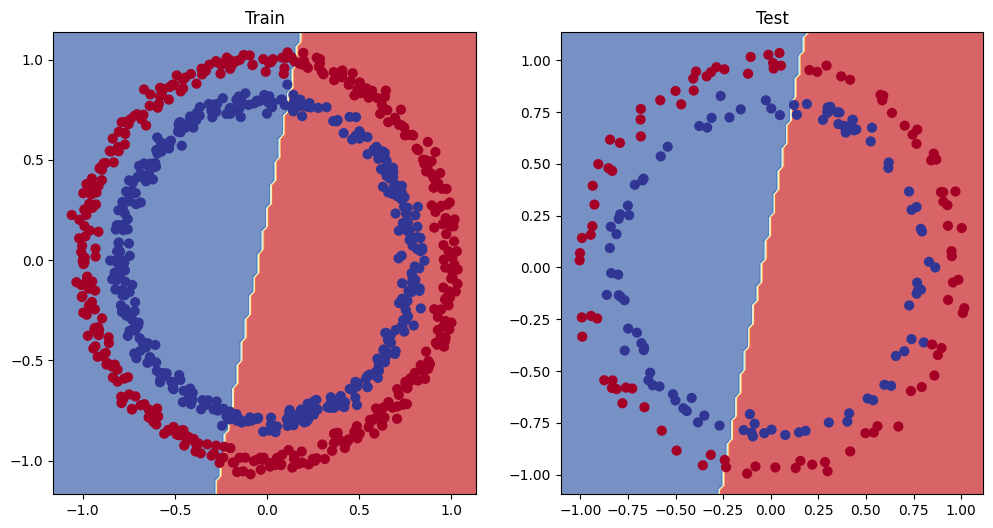

In [23]:
# Plot decision boundaries for training and test sets
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_0, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_0, X_test, y_test)

- 모델이 현재 빨간 점 & 파란 점을 직선 하나로 나누려 하고 있음 -> 정확도 50%에 머뭄
- 우리 데이터는 원형 구조인데 직선을 그려서 나누면 아무리 잘해도 반으로 가르는 수준

-> 이를 언더피팅(underfitting) 상태라고 함 <br>
: 데이터로부터 의미 있는 예측 패턴을 학습하지 못하고 있음

# 5) 모델 개선하기 (모델 관점에서)
- 데이터 자체가 아닌 모델 자체에만 초점을 맞춰서 모델의 언더피팅 문데 해결해보기

- 모델 개선 기법 (model improvement techiniques)
1. 레이어 수 늘리기 <br>
각 레이어는 데이터에서 새로운 패턴을 학습할 수 있는 잠재력을 가짐. 레이어가 많아질수록 신경망은 더 깊어졌다(deeper) 고 표현함
2. 은닉 유닛 수 늘리기 <br>
각 레이어에 더 많은 은닉 유닛을 두면 모델의 학습 능력이 증가할 수 있다. 이런 경우 신경망이 더 넓어졌다(wider) 고 말한다.
3. 더 오래 학습하기 (에폭 수 증가)<br>
모델이 데이터를 더 많이 볼수록 더 많은 패턴을 학습할 가능성이 있다.
4. 활성화 함수 변경하기<br>
어떤 데이터는 직선만으로는 잘 맞출 수 없다(우리가 방금 본 것처럼). 이런 경우 비선형 활성화 함수를 사용하면 도움이 된다
5. 학습률 변경하기<br>
모델 구조보다는 옵티마이저와 관련되지만 중요한 요소다. 학습률은 한 단계마다 파라미터를 얼마나 크게 업데이트할지 결정한다. 너무 크면 과도하게 보정(overcorrect)하고, 너무 작으면 충분히 학습하지 못한다.
6. 손실 함수 변경하기<br>
이것도 모델 구조보다는 문제 유형과 관련 있다. 예를 들어, 이진 교차 엔트로피 손실 함수는 다중 클래스 분류 문제에는 사용할 수 없다.
7. 전이 학습 사용하기 (Transfer learning)   <br>
현재 문제와 유사한 도메인에서 사전 학습된 모델을 가져와서 내 문제에 맞게 조정한다. 전이 학습은 노트북 06에서 다룬다.

In [24]:
class CircleModelV1(nn.Module):
    def __init__(self):
        super().__init__()
        # 첫 번째 선형 레이어 - 입력 특성 수: 원 데이터가(x좌표, y좌표)같은 2차원 특징이라서 2, 출력 유닛 수 : 은닉 유닛 10개로 확장(=너비 늘림)
        self.layer_1 = nn.Linear(in_features=2, out_features=10) 
        self.layer_2 = nn.Linear(in_features=10, out_features=10)   # 추가 레이어 (깊이 늘림)
        self.layer_3 = nn.Linear(in_features=10, out_features=1)
    
    def forward(self, x):
        return self.layer_3(self.layer_2(self.layer_1(x))) # sigmoid 적용 전이라 최종 반환값은 logits
    
model_1 = CircleModelV1().to(device)
model_1

CircleModelV1(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
)

In [25]:
# Loss_fn = nn.BCELoss()  # 입력값에 sigmoid가 적용되어 있어야 함

#이진 분류용 손실 함수 생성
loss_fn = nn.BCEWithLogitsLoss() # 모델의 원시 출력값(logits)을 그대로 입력으로 받음. 내부에 (sigmoid+binary cross entropy) 들어있음. 수치적으로 더 안정적.
#확률적 경사 하강법(SGD) 옵티마이저 생성
optimizer = torch.optim.SGD(model_1.parameters(), lr=0.1)  # model_1.parameters(): 학습대상- 모델의 모든 가중치&편향

- epochs=1000으로 설정해서 앞에서 한 일반적인 훈련 루프 단계를 사용해 모델 학습시키기

*지금까지 비슷한 형태의 훈련 루프 코드를 반복해서 작성했는데 이 코드를 함수화한다면? <br>
-훈련용 함수(train function) <br>
-테스트용 함수(test function) <br>



In [30]:
torch.manual_seed(42)

epochs = 1000 # 더 오래 학습

X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

for epoch in range(epochs):
    ### training
    # 1. forward pass
    y_logits = model_1(X_train).squeeze()
    y_pred = torch.round(torch.sigmoid(y_logits)) # logits(원시 출력값) -> 예측 확률 -> 예측된 클래스(라벨)
    
    # 2. 손실/정확도 계산
    loss = loss_fn(y_logits, y_train)
    acc = accuracy_fn(y_true=y_train,   # y_train(정답 라벨)과 y_pred(0/1 예측 라벨) 비교해 % 산출
                      y_pred=y_pred)
    
    # 3. gradient 초기화
    optimizer.zero_grad()
    
    # 4. loss backwards
    loss.backward()
    
    # 5. 파라미터 업데이트
    optimizer.step()
    
    ### testing 
    model_1.eval()
    with torch.inference_mode():
        # 1. forward pass
        test_logits = model_1(X_test).squeeze() # 테스트 데이터의 logits 계산
        test_pred = torch.round(torch.sigmoid(test_logits)) # logits → sigmoid → 확률 → round → 0/1 라벨
        # 2. 테스트 손실/ 정확도 계산
        test_loss = loss_fn(test_logits,
                            y_test)
        test_acc = accuracy_fn(y_true=y_test,
                               y_pred=test_pred)
        
    if epoch % 100 ==0:
         print(f"Epoch: {epoch} | Loss: {loss:.5f}, Accuracy: {acc:.2f}% | Test loss: {test_loss:.5f}, Test acc: {test_acc:.2f}%")
        

Epoch: 0 | Loss: 0.69298, Accuracy: 51.00% | Test loss: 0.69468, Test acc: 46.00%
Epoch: 100 | Loss: 0.69298, Accuracy: 51.00% | Test loss: 0.69468, Test acc: 46.00%
Epoch: 200 | Loss: 0.69298, Accuracy: 51.00% | Test loss: 0.69468, Test acc: 46.00%
Epoch: 300 | Loss: 0.69298, Accuracy: 51.00% | Test loss: 0.69468, Test acc: 46.00%
Epoch: 400 | Loss: 0.69298, Accuracy: 51.00% | Test loss: 0.69468, Test acc: 46.00%
Epoch: 500 | Loss: 0.69298, Accuracy: 51.00% | Test loss: 0.69468, Test acc: 46.00%
Epoch: 600 | Loss: 0.69298, Accuracy: 51.00% | Test loss: 0.69468, Test acc: 46.00%
Epoch: 700 | Loss: 0.69298, Accuracy: 51.00% | Test loss: 0.69468, Test acc: 46.00%
Epoch: 800 | Loss: 0.69298, Accuracy: 51.00% | Test loss: 0.69468, Test acc: 46.00%
Epoch: 900 | Loss: 0.69298, Accuracy: 51.00% | Test loss: 0.69468, Test acc: 46.00%


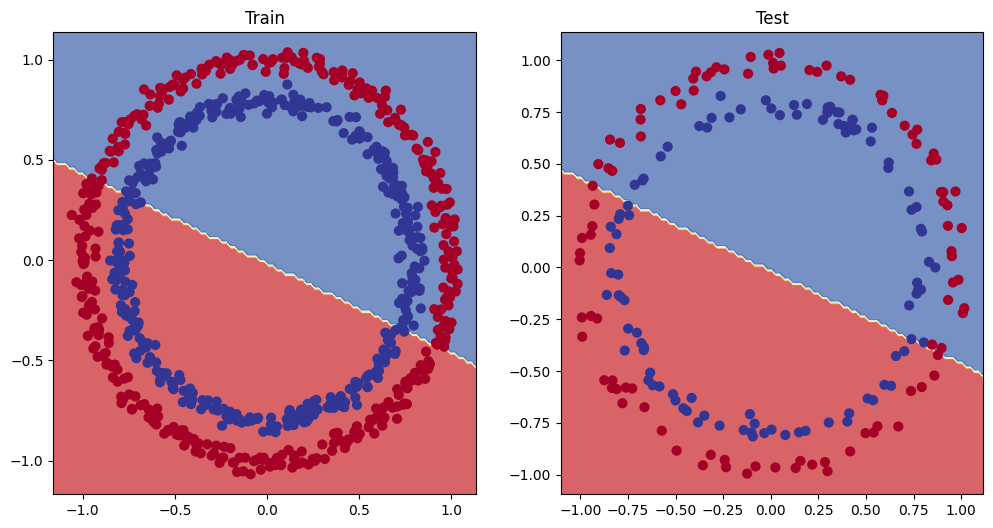

In [34]:
# 훈련 & 테스트 데이터에 대한 결정 경계를 그림
plt.figure(figsize=(12,6))  # 가로 12, 세로 6의 하나의 큰 그림 생성
plt.subplot(1, 2, 1)    # 1행 2열짜리 subplot 중 첫 번째 위치. 즉, 왼쪽 그래프 자리
plt.title("Train")  # 왼쪽 그래프의 제목을 "Train"으로 설정. 훈련 데이터 기준 결정 경계
plot_decision_boundary(model_1, X_train, y_train)
# plot_decision_boundary(): 입력 공간 전체에 격자를 깔고 각 점을 model_1에 넣어서 모델이 어떤 클래스로 예측하는지 계산. 그 결과를 색으로 칠해 결정 경계 시각화. 그 위에 실제 데이터 점(X_train, y_train) 함께 표시
# 결과 - 배경색: 모델이 예측한 클래스 영역.     점들: 실제 훈련 데이터.     경계: 모델이 0/1을 나누는 기준
plt.subplot(1, 2, 2)    # 1행 2열짜리 subplot 중 두 번째 위치. 즉, 오른쪽 그래프 자리
plt.title("Test")   # 오른쪽 그래프 제목을 Test로. 훈련에 쓰지 않은 데이터에서의 결정 경계
plot_decision_boundary(model_1, X_test, y_test) # 테스트 데이터 기준으로 같은 시각화 수행. 모델이 보지 않은 데이터에도 같은 패턴으로 잘 나누는지 확인.

*subplot : 하나의 큰 그림 안에 여러 개의 작은 그래프를 배치하는 것

# 5.1) 직선 데이터를 모델링할 수 있는지 확인하기 위한 데이터 준비
- 모델이 정말로 아무것도 학습하지 못하는 모델인지 직선 형태의 데이터는 잘 학습할 수 있는 모델인지를 확인하기 위해 선형 데이터 만들어보기

In [35]:
# create some data 
weight = 0.7
bias = 0.3
start = 0
end = 1
step = 0.01

X_regression = torch.arange(start, end, step).unsqueeze(dim=1)
y_regression = weight * X_regression + bias # linear regression formula

# Check the data
print(len(X_regression))
X_regression[:5], y_regression[:5]

100


(tensor([[0.0000],
         [0.0100],
         [0.0200],
         [0.0300],
         [0.0400]]),
 tensor([[0.3000],
         [0.3070],
         [0.3140],
         [0.3210],
         [0.3280]]))

In [36]:
train_split = int(0.8 * len(X_regression)) # 데이터의 80%가 학습세트로 사용됨
X_train_regression, y_train_regression = X_regression[:train_split], y_regression[:train_split]
X_test_regression, y_test_regression = X_regression[train_split:], y_regression[train_split:]

# 각 분할의 길이를 확인
print(len(X_train_regression), 
    len(y_train_regression), 
    len(X_test_regression), 
    len(y_test_regression))

80 80 20 20


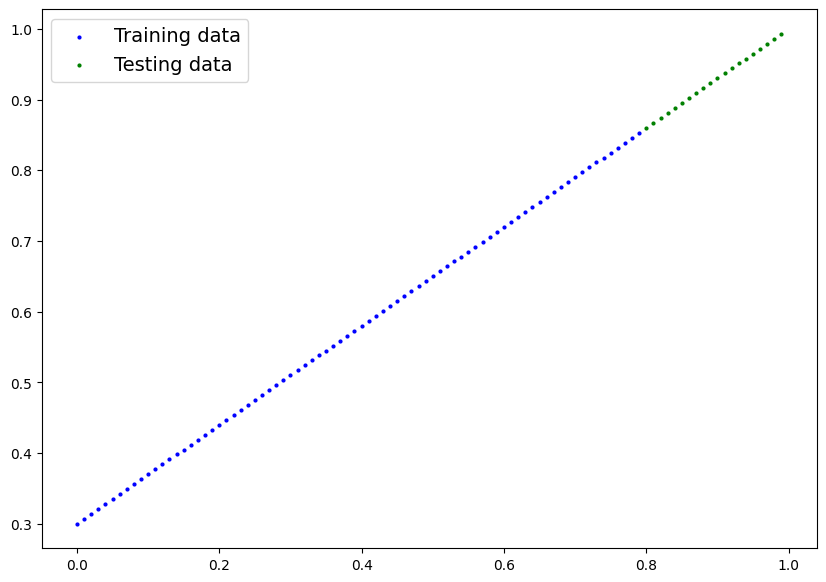

In [37]:
plot_predictions(train_data=X_train_regression,
    train_labels=y_train_regression,
    test_data=X_test_regression,
    test_labels=y_test_regression
);

# 5.2) 직선을 학습하도록 model_1 조정
- 회귀 데이터에 적합한 손실 함수 사용해서 model_1 다시 만들기 <br>
-> 분류 문제에 맞춰졌던 설정을 버리고 직선(연속값)을 잘 맞출 수 있는 모델 설정으로 바꿈

*nn.Sequential : 여러 레이어를 위에서 아래로 자동으로 연결해주는 컨테이너

In [38]:
# model_1과 같은 설계지만 nn.Sequential 방식으로 정의함 (class X)
model_2 = nn.Sequential(    
    nn.Linear(in_features=1, out_features=10),  # 첫 번째 선형 레이어. 입력 특성 수 = 1 -> 선형 회귀 데이터라 x값 하나. 출력 =10 -> 은닉 유닛 10개
    nn.Linear(in_features=10, out_features=10), # 두 번째 선형 레이어. 은닉층 -> 은닉층 (10 -> 10)
    nn.Linear(in_features=10, out_features=1)   # 출력 레이어. 최종 예측값 1개 -> 연속적인 y값 예측 (회귀)
).to(device)    # 모델 전체를 CPU 또는 GPU(device) 로 이동

model_2

Sequential(
  (0): Linear(in_features=1, out_features=10, bias=True)
  (1): Linear(in_features=10, out_features=10, bias=True)
  (2): Linear(in_features=10, out_features=1, bias=True)
)

*biras=True : 편향을 사용함
- epochs = 1000 으로 설정해서 앞에서 사용했던 일반적인 (training loop) 학습 단계 그대로 이용해 모델 학습시키기

In [39]:
torch.manual_seed(42)
epcohs = 1000

# 데이터 device 이동
X_train_regression, y_train_regression = X_train_regression.to(device), y_train_regression.to(device)
X_test_regression, y_test_regression = X_test_regression.to(device), y_test_regression.to(device)

for epoch in range(epochs) :
    ### training
    # 1. 순전파 (forward pass)
    y_pred = model_2(X_train_regression)        # 회귀 문제라 sigmoid&round X
    
    # 2. 손실 계산 (분류가 아니라 회귀 문제이기에 정확도 x)
    loss = loss_fn(y_pred, y_train_regression)
    
    # 3. optimizer gradient 초기화
    optimizer.zero_grad()
    
    # 4. loss backwards
    loss.backward()
    
    # 5. optimizer step
    optimizer.step
    
    ### testing
    model_2.eval()
    with torch.inference_mode():
        # 1. foward pass
        test_pred = model_2(X_test_regression)
        # 2. 손실 계산
        test_loss = loss_fn(test_pred, y_test_regression)
        
    if epoch % 100 ==0:
        print(f"Epoch: {epoch} | Train loss: {loss:.5f}, Test loss: {test_loss:.5f}")
                                                                                          


Epoch: 0 | Train loss: 0.70037, Test loss: 0.70427
Epoch: 100 | Train loss: 0.70037, Test loss: 0.70427
Epoch: 200 | Train loss: 0.70037, Test loss: 0.70427
Epoch: 300 | Train loss: 0.70037, Test loss: 0.70427
Epoch: 400 | Train loss: 0.70037, Test loss: 0.70427
Epoch: 500 | Train loss: 0.70037, Test loss: 0.70427
Epoch: 600 | Train loss: 0.70037, Test loss: 0.70427
Epoch: 700 | Train loss: 0.70037, Test loss: 0.70427
Epoch: 800 | Train loss: 0.70037, Test loss: 0.70427
Epoch: 900 | Train loss: 0.70037, Test loss: 0.70427


--> 분류 데이터에서의 model_1과는 다르게 model_2의 손실(loss)이 실제로 감소하고 있는 것처럼 보임

* 현재 모델과 데이터는 target device를 사용하고 있고  이 device는 GPU일 수도 있다.
하지만 우리가 사용하는 matplotlib 기반의 시각화 함수는 GPU 텐서를 처리할 수 없음

그래서 이를 해결하기 위해,
plot_predictions() 함수에 데이터를 전달할 때는
.cpu()를 사용해 모든 데이터를 CPU로 옮겨서 넘겨줄 것임

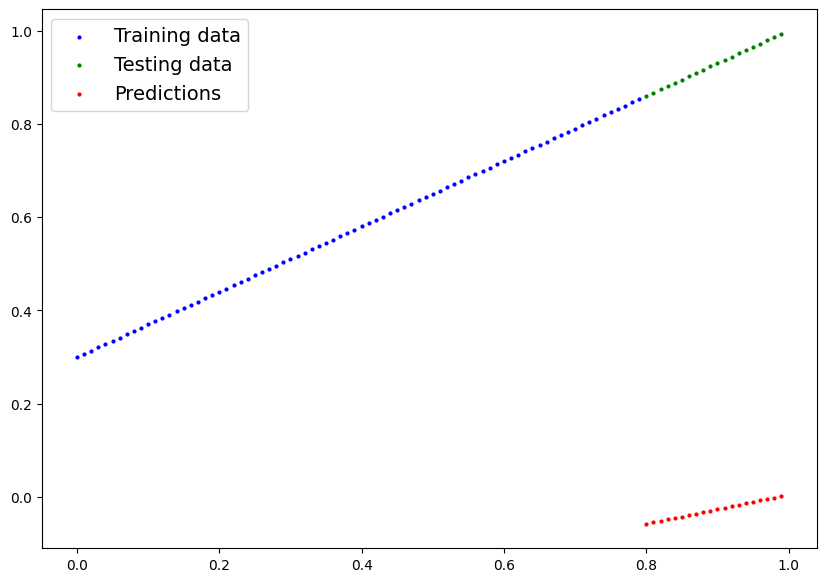

In [40]:
# 모델을 평가 모드로 전환 
model_2.eval()

# 예측 수행
with torch.inference_mode():
    y_preds = model_2(X_test_regression)    # 테스트 입력 데이터(X_test_regression)를 모델에 넣어 예측값(y_preds) 생성

# 데이터를 CPU로 옮겨서 시각화. matplotlib은 GPU 텐서를 처리하지 못함
# .cpu()를 제거하면 에러 남
plot_predictions(train_data=X_train_regression.cpu(),
                 train_labels=y_train_regression.cpu(),
                 test_data=X_test_regression.cpu(),
                 test_labels=y_test_regression.cpu(),
                 predictions=y_preds.cpu());

직선 데이터에서는 무작위 추측보다 훨씬 잘 동작함 -> 이 모델이 학습할 수 있는 능력이 있음을 암시